# Supply Chain Risk & Logistics — EDA & Preprocessing
**15.071 Final Project** | Avery Reischer-Craft · Carla Choueifaty · Cathy Liu

**Targets:**
- `Disruption_Occurred` → Classification (Logistic Regression, CART)
- `Lead_Time_Days` → Regression (Linear Regression, CART)

**Dataset:** Global Supply Chain Risk & Logistics 2024–2026 (5,000 shipments)

## 0. Imports & Setup

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle, os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# ── Plot style
C0, C1 = '#2E86AB', '#E84855'   # blue = no disruption, red = disruption
GRAY   = '#6c757d'
BG     = '#F8F9FA'
plt.rcParams.update({'font.family': 'sans-serif', 'font.size': 10})

SEED = 123

# ── Plot output directory
PLOT_DIR = 'plots'
os.makedirs(PLOT_DIR, exist_ok=True)
print(f'Plots will be saved to: {os.path.abspath(PLOT_DIR)}')


Plots will be saved to: /Users/yichengliu/Downloads/plots


## 1. Load Data

In [5]:
df = pd.read_csv('global_supply_chain_risk_2026.csv')
print(f'Shape: {df.shape}')
df.head()


Shape: (5000, 14)


,Shipment_ID,Date,Origin_Port,Destination_Port,Transport_Mode,Product_Category,Distance_km,Weight_MT,Fuel_Price_Index,Geopolitical_Risk_Score,Weather_Condition,Carrier_Reliability_Score,Lead_Time_Days,Disruption_Occurred
0,SC-10000,2025-10-16,Singapore,Los Angeles,Rail,Textiles,5930.83,197.42,2.43,5.0,Hurricane,0.865,41.39,1
1,SC-10001,2024-04-24,Singapore,Shanghai,Rail,Automotive,14285.36,237.24,2.30,7.5,Storm,0.592,40.92,1
2,SC-10002,2024-01-26,Rotterdam,Los Angeles,Rail,Perishables,11113.91,427.42,1.78,5.6,Rain,0.673,11.54,0
3,SC-10003,2024-10-08,Busan,Hamburg,Rail,Electronics,9180.55,170.66,3.20,0.8,Hurricane,0.832,53.13,1
4,SC-10004,2024-09-07,Busan,Singapore,Air,Perishables,2762.27,434.96,2.77,1.9,Fog,0.741,0.50,1


In [6]:
# Column types and missing value audit
audit = pd.DataFrame({
    'dtype':       df.dtypes,
    'missing':     df.isnull().sum(),
    'pct_missing': (df.isnull().mean() * 100).round(2)
})
print(audit)


                             dtype  missing  pct_missing
Shipment_ID                 object        0          0.0
Date                        object        0          0.0
Origin_Port                 object        0          0.0
Destination_Port            object        0          0.0
Transport_Mode              object        0          0.0
Product_Category            object        0          0.0
Distance_km                float64        0          0.0
Weight_MT                  float64        0          0.0
Fuel_Price_Index           float64        0          0.0
Geopolitical_Risk_Score    float64        0          0.0
Weather_Condition           object        0          0.0
Carrier_Reliability_Score  float64        0          0.0
Lead_Time_Days             float64        0          0.0
Disruption_Occurred          int64        0          0.0


In [7]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
Distance_km,5000.0,7704.063888,4199.687885,500.17,4036.010,7750.125,11347.4625,14995.91
Weight_MT,5000.0,246.252052,142.522591,1.03,124.330,243.500,366.9550,499.75
Fuel_Price_Index,5000.0,2.854552,0.959533,1.20,2.020,2.840,3.7100,4.50
Geopolitical_Risk_Score,5000.0,5.076900,2.877832,0.00,2.600,5.100,7.5000,10.00
Carrier_Reliability_Score,5000.0,0.754387,0.144363,0.50,0.629,0.757,0.8790,1.00
Lead_Time_Days,5000.0,19.355386,31.405143,0.50,2.110,8.245,21.2075,236.39
Disruption_Occurred,5000.0,0.612600,0.487205,0.00,0.000,1.000,1.0000,1.00


In [8]:
# Unique values per categorical column
for col in ['Origin_Port','Destination_Port','Transport_Mode',
            'Product_Category','Weather_Condition']:
    print(f'{col} ({df[col].nunique()} unique): {sorted(df[col].unique())}')


Origin_Port (8 unique): ['Antwerp', 'Busan', 'Dubai', 'Hamburg', 'Los Angeles', 'Rotterdam', 'Shanghai', 'Singapore']
Destination_Port (9 unique): ['Antwerp', 'Busan', 'Dubai', 'Hamburg', 'Los Angeles', 'Marseille', 'Rotterdam', 'Shanghai', 'Singapore']
Transport_Mode (4 unique): ['Air', 'Rail', 'Road', 'Sea']
Product_Category (5 unique): ['Automotive', 'Electronics', 'Perishables', 'Pharmaceuticals', 'Textiles']
Weather_Condition (5 unique): ['Clear', 'Fog', 'Hurricane', 'Rain', 'Storm']


## 2. Exploratory Data Analysis

### 2.1 Target Variables

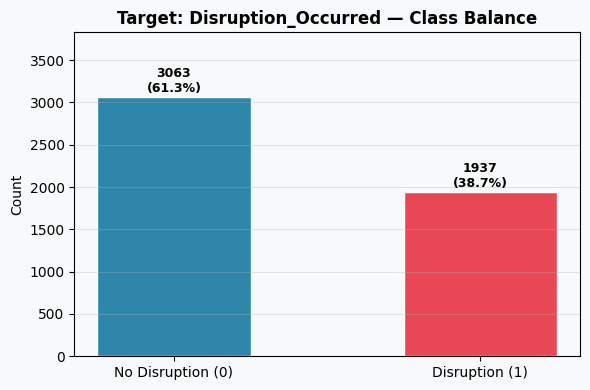

In [11]:
# ── Plot 01: Class balance 
fig, ax = plt.subplots(figsize=(6, 4), facecolor=BG)
counts = df['Disruption_Occurred'].value_counts()
bars = ax.bar(['No Disruption (0)', 'Disruption (1)'], counts.values,
              color=[C0, C1], edgecolor='white', width=0.5)
for b, v in zip(bars, counts.values):
    ax.text(b.get_x()+b.get_width()/2, v+30, f'{v}\n({v/len(df)*100:.1f}%)',
            ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_title('Target: Disruption_Occurred — Class Balance', fontweight='bold')
ax.set_ylabel('Count'); ax.set_ylim(0, counts.max()*1.25)
ax.set_facecolor(BG); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/01_target_class_balance.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


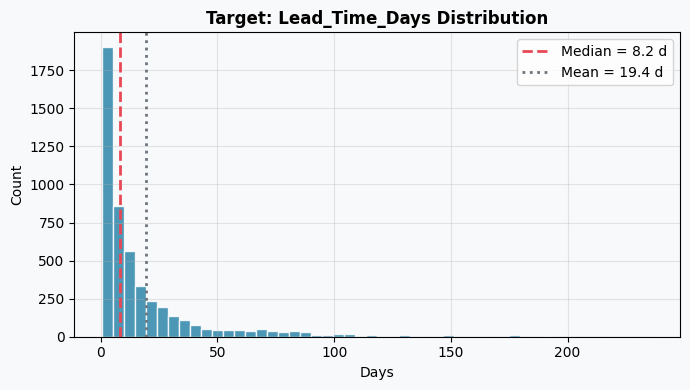

In [12]:
# ── Plot 02: Lead_Time overall distribution
fig, ax = plt.subplots(figsize=(7, 4), facecolor=BG)
ax.hist(df['Lead_Time_Days'], bins=50, color=C0, edgecolor='white', alpha=0.85)
ax.axvline(df['Lead_Time_Days'].median(), color=C1, lw=2, ls='--',
           label=f"Median = {df['Lead_Time_Days'].median():.1f} d")
ax.axvline(df['Lead_Time_Days'].mean(), color=GRAY, lw=2, ls=':',
           label=f"Mean = {df['Lead_Time_Days'].mean():.1f} d")
ax.set_title('Target: Lead_Time_Days Distribution', fontweight='bold')
ax.set_xlabel('Days'); ax.set_ylabel('Count')
ax.legend(); ax.set_facecolor(BG); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/02_lead_time_distribution.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


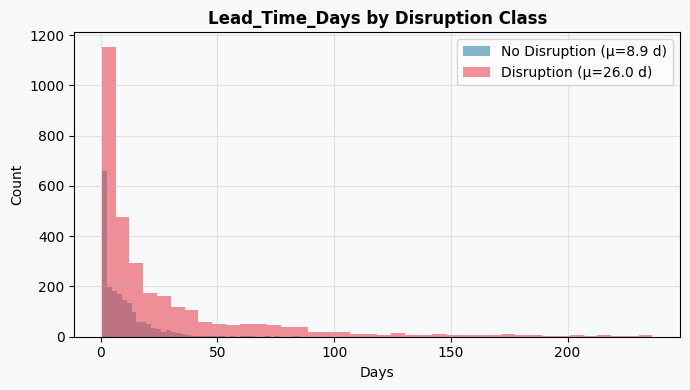

In [13]:
# ── Plot 03: Lead_Time by disruption class
fig, ax = plt.subplots(figsize=(7, 4), facecolor=BG)
for val, color, label in zip([0,1],[C0,C1],['No Disruption','Disruption']):
    sub = df[df['Disruption_Occurred']==val]['Lead_Time_Days']
    ax.hist(sub, bins=40, color=color, alpha=0.6,
            label=f'{label} (μ={sub.mean():.1f} d)')
ax.set_title('Lead_Time_Days by Disruption Class', fontweight='bold')
ax.set_xlabel('Days'); ax.set_ylabel('Count')
ax.legend(); ax.set_facecolor(BG); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/03_lead_time_by_disruption.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


### 2.2 Numeric Features vs Disruption

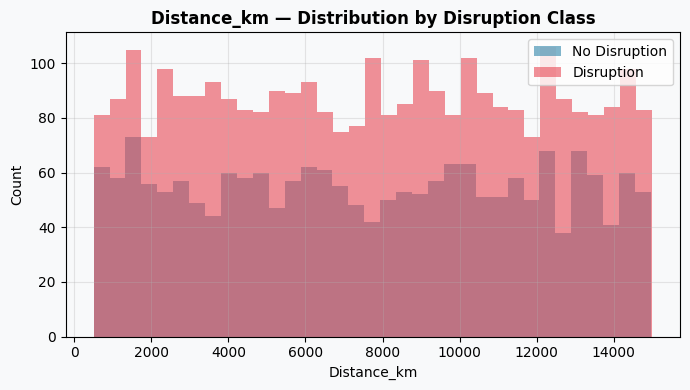

In [15]:
# ── Plot 04: Distance_km
fig, ax = plt.subplots(figsize=(7, 4), facecolor=BG)
for val, color, label in zip([0,1],[C0,C1],['No Disruption','Disruption']):
    sub = df[df['Disruption_Occurred']==val]['Distance_km']
    ax.hist(sub, bins=35, color=color, alpha=0.6, label=label)
ax.set_title('Distance_km — Distribution by Disruption Class', fontweight='bold')
ax.set_xlabel('Distance_km'); ax.set_ylabel('Count')
ax.legend(); ax.set_facecolor(BG); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/04_num_distance_km.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


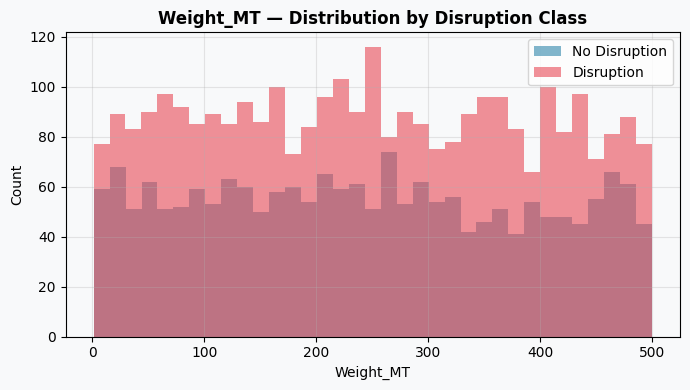

In [16]:
# ── Plot 05: Weight_MT
fig, ax = plt.subplots(figsize=(7, 4), facecolor=BG)
for val, color, label in zip([0,1],[C0,C1],['No Disruption','Disruption']):
    sub = df[df['Disruption_Occurred']==val]['Weight_MT']
    ax.hist(sub, bins=35, color=color, alpha=0.6, label=label)
ax.set_title('Weight_MT — Distribution by Disruption Class', fontweight='bold')
ax.set_xlabel('Weight_MT'); ax.set_ylabel('Count')
ax.legend(); ax.set_facecolor(BG); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/05_num_weight_mt.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


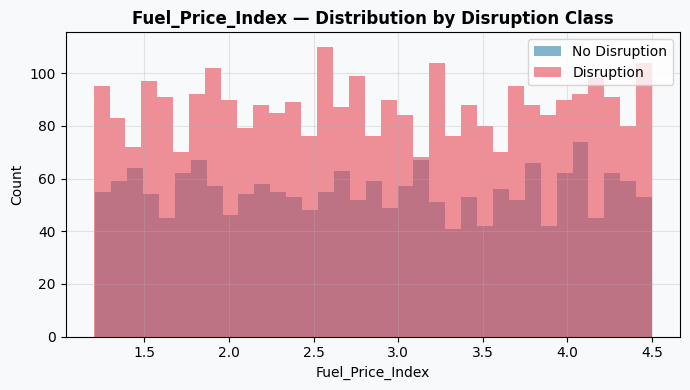

In [17]:
# ── Plot 06: Fuel_Price_Index
fig, ax = plt.subplots(figsize=(7, 4), facecolor=BG)
for val, color, label in zip([0,1],[C0,C1],['No Disruption','Disruption']):
    sub = df[df['Disruption_Occurred']==val]['Fuel_Price_Index']
    ax.hist(sub, bins=35, color=color, alpha=0.6, label=label)
ax.set_title('Fuel_Price_Index — Distribution by Disruption Class', fontweight='bold')
ax.set_xlabel('Fuel_Price_Index'); ax.set_ylabel('Count')
ax.legend(); ax.set_facecolor(BG); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/06_num_fuel_price_index.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


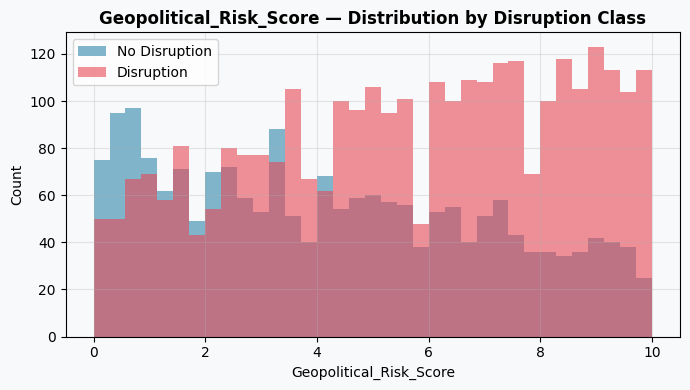

In [18]:
# ── Plot 07: Geopolitical_Risk_Score
fig, ax = plt.subplots(figsize=(7, 4), facecolor=BG)
for val, color, label in zip([0,1],[C0,C1],['No Disruption','Disruption']):
    sub = df[df['Disruption_Occurred']==val]['Geopolitical_Risk_Score']
    ax.hist(sub, bins=35, color=color, alpha=0.6, label=label)
ax.set_title('Geopolitical_Risk_Score — Distribution by Disruption Class', fontweight='bold')
ax.set_xlabel('Geopolitical_Risk_Score'); ax.set_ylabel('Count')
ax.legend(); ax.set_facecolor(BG); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/07_num_geopolitical_risk_score.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


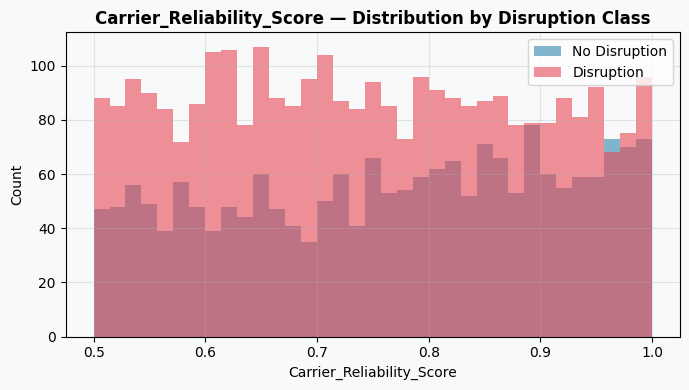

In [19]:
# ── Plot 08: Carrier_Reliability_Score
fig, ax = plt.subplots(figsize=(7, 4), facecolor=BG)
for val, color, label in zip([0,1],[C0,C1],['No Disruption','Disruption']):
    sub = df[df['Disruption_Occurred']==val]['Carrier_Reliability_Score']
    ax.hist(sub, bins=35, color=color, alpha=0.6, label=label)
ax.set_title('Carrier_Reliability_Score — Distribution by Disruption Class', fontweight='bold')
ax.set_xlabel('Carrier_Reliability_Score'); ax.set_ylabel('Count')
ax.legend(); ax.set_facecolor(BG); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/08_num_carrier_reliability_score.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


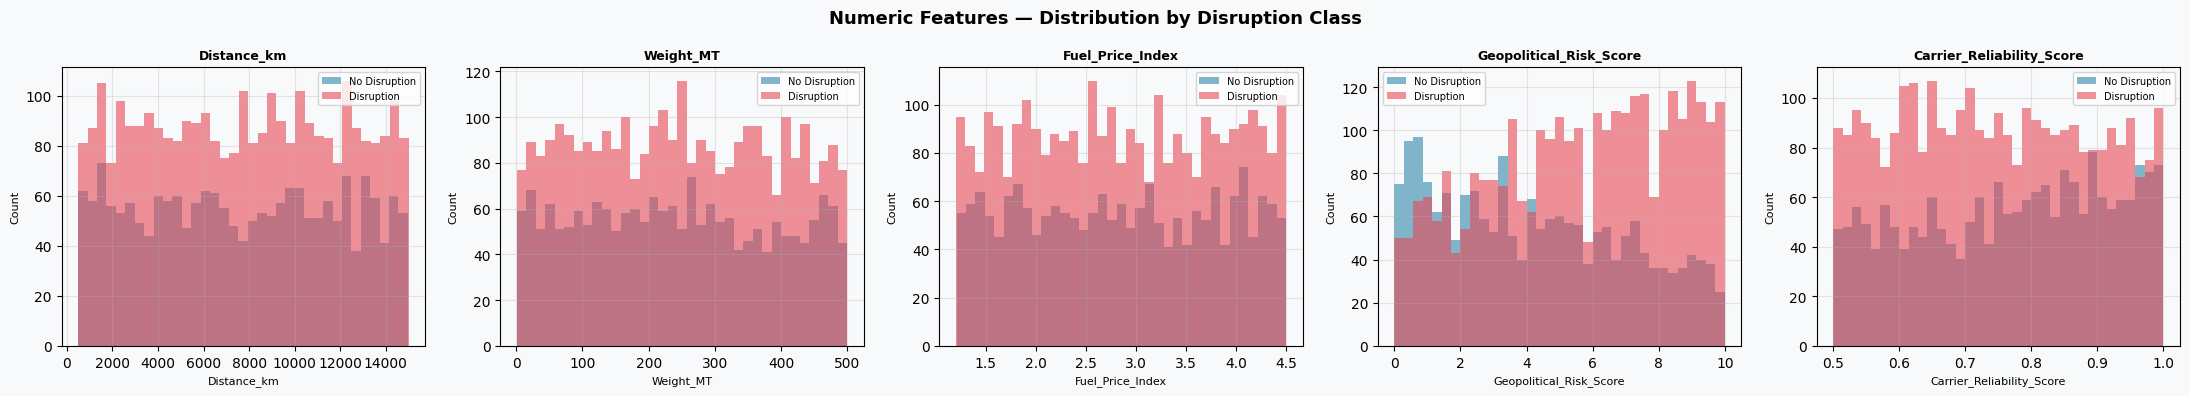

In [20]:
# ── Plot 09: Numeric panel (all 5 features side by side)
num_cols = ['Distance_km','Weight_MT','Fuel_Price_Index',
            'Geopolitical_Risk_Score','Carrier_Reliability_Score']
fig, axes = plt.subplots(1, 5, figsize=(22, 4), facecolor=BG)
fig.suptitle('Numeric Features — Distribution by Disruption Class',
             fontsize=13, fontweight='bold')
for ax, col in zip(axes, num_cols):
    for val, color, label in zip([0,1],[C0,C1],['No Disruption','Disruption']):
        sub = df[df['Disruption_Occurred']==val][col]
        ax.hist(sub, bins=35, color=color, alpha=0.6, label=label)
    ax.set_title(col, fontweight='bold', fontsize=9)
    ax.set_xlabel(col, fontsize=8); ax.set_ylabel('Count', fontsize=8)
    ax.legend(fontsize=7); ax.set_facecolor(BG); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/09_numeric_features_panel.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


### 2.3 Categorical Features — Disruption Rate

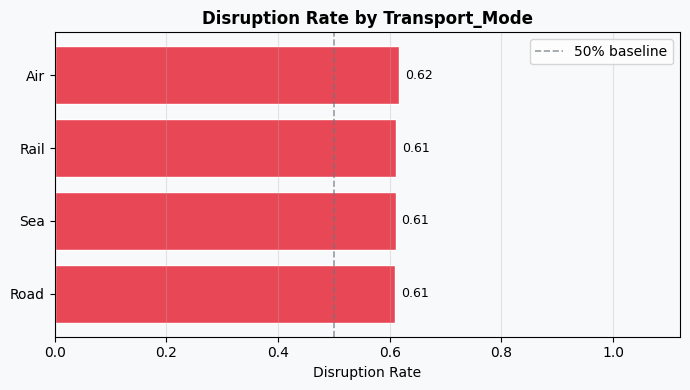

In [22]:
# ── Plot 10: Transport_Mode
fig, ax = plt.subplots(figsize=(7, 4), facecolor=BG)
rates = df.groupby('Transport_Mode')['Disruption_Occurred'].mean().sort_values()
colors = [C1 if r > 0.5 else C0 for r in rates.values]
bars = ax.barh(rates.index, rates.values, color=colors, edgecolor='white')
ax.axvline(0.5, color=GRAY, lw=1.2, ls='--', alpha=0.7, label='50% baseline')
for bar, v in zip(bars, rates.values):
    ax.text(v+0.01, bar.get_y()+bar.get_height()/2,
            f'{v:.2f}', va='center', fontsize=9)
ax.set_title('Disruption Rate by Transport_Mode', fontweight='bold')
ax.set_xlabel('Disruption Rate'); ax.set_xlim(0, 1.12)
ax.legend(); ax.set_facecolor(BG); ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/10_cat_transport_mode.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


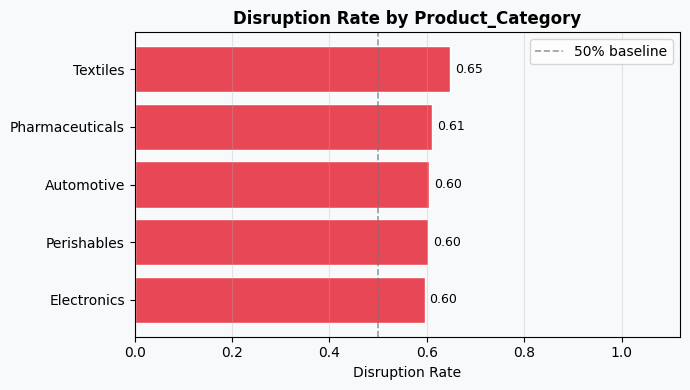

In [23]:
# ── Plot 11: Product_Category
fig, ax = plt.subplots(figsize=(7, 4), facecolor=BG)
rates = df.groupby('Product_Category')['Disruption_Occurred'].mean().sort_values()
colors = [C1 if r > 0.5 else C0 for r in rates.values]
bars = ax.barh(rates.index, rates.values, color=colors, edgecolor='white')
ax.axvline(0.5, color=GRAY, lw=1.2, ls='--', alpha=0.7, label='50% baseline')
for bar, v in zip(bars, rates.values):
    ax.text(v+0.01, bar.get_y()+bar.get_height()/2,
            f'{v:.2f}', va='center', fontsize=9)
ax.set_title('Disruption Rate by Product_Category', fontweight='bold')
ax.set_xlabel('Disruption Rate'); ax.set_xlim(0, 1.12)
ax.legend(); ax.set_facecolor(BG); ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/11_cat_product_category.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


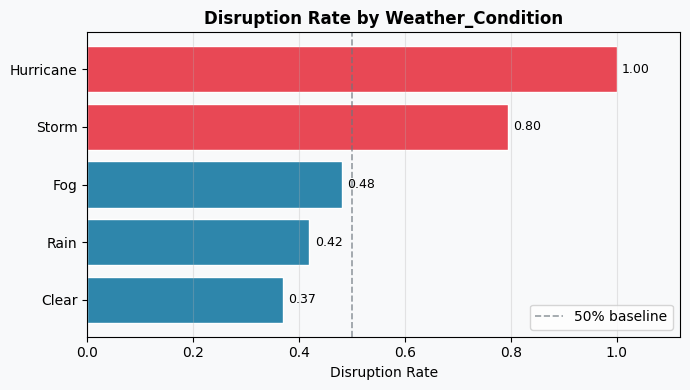

In [24]:
# ── Plot 12: Weather_Condition
fig, ax = plt.subplots(figsize=(7, 4), facecolor=BG)
rates = df.groupby('Weather_Condition')['Disruption_Occurred'].mean().sort_values()
colors = [C1 if r > 0.5 else C0 for r in rates.values]
bars = ax.barh(rates.index, rates.values, color=colors, edgecolor='white')
ax.axvline(0.5, color=GRAY, lw=1.2, ls='--', alpha=0.7, label='50% baseline')
for bar, v in zip(bars, rates.values):
    ax.text(v+0.01, bar.get_y()+bar.get_height()/2,
            f'{v:.2f}', va='center', fontsize=9)
ax.set_title('Disruption Rate by Weather_Condition', fontweight='bold')
ax.set_xlabel('Disruption Rate'); ax.set_xlim(0, 1.12)
ax.legend(); ax.set_facecolor(BG); ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/12_cat_weather_condition.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


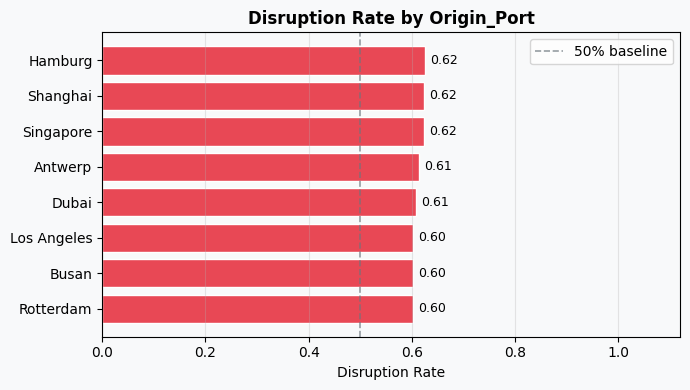

In [25]:
# ── Plot 13: Origin_Port
fig, ax = plt.subplots(figsize=(7, 4), facecolor=BG)
rates = df.groupby('Origin_Port')['Disruption_Occurred'].mean().sort_values()
colors = [C1 if r > 0.5 else C0 for r in rates.values]
bars = ax.barh(rates.index, rates.values, color=colors, edgecolor='white')
ax.axvline(0.5, color=GRAY, lw=1.2, ls='--', alpha=0.7, label='50% baseline')
for bar, v in zip(bars, rates.values):
    ax.text(v+0.01, bar.get_y()+bar.get_height()/2,
            f'{v:.2f}', va='center', fontsize=9)
ax.set_title('Disruption Rate by Origin_Port', fontweight='bold')
ax.set_xlabel('Disruption Rate'); ax.set_xlim(0, 1.12)
ax.legend(); ax.set_facecolor(BG); ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/13_cat_origin_port.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


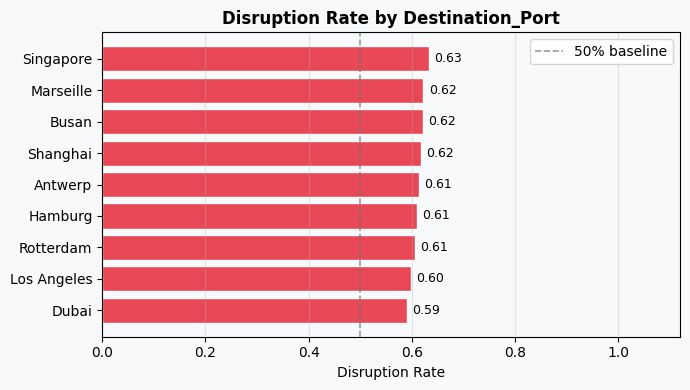

In [26]:
# ── Plot 14: Destination_Port
fig, ax = plt.subplots(figsize=(7, 4), facecolor=BG)
rates = df.groupby('Destination_Port')['Disruption_Occurred'].mean().sort_values()
colors = [C1 if r > 0.5 else C0 for r in rates.values]
bars = ax.barh(rates.index, rates.values, color=colors, edgecolor='white')
ax.axvline(0.5, color=GRAY, lw=1.2, ls='--', alpha=0.7, label='50% baseline')
for bar, v in zip(bars, rates.values):
    ax.text(v+0.01, bar.get_y()+bar.get_height()/2,
            f'{v:.2f}', va='center', fontsize=9)
ax.set_title('Disruption Rate by Destination_Port', fontweight='bold')
ax.set_xlabel('Disruption Rate'); ax.set_xlim(0, 1.12)
ax.legend(); ax.set_facecolor(BG); ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/14_cat_destination_port.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


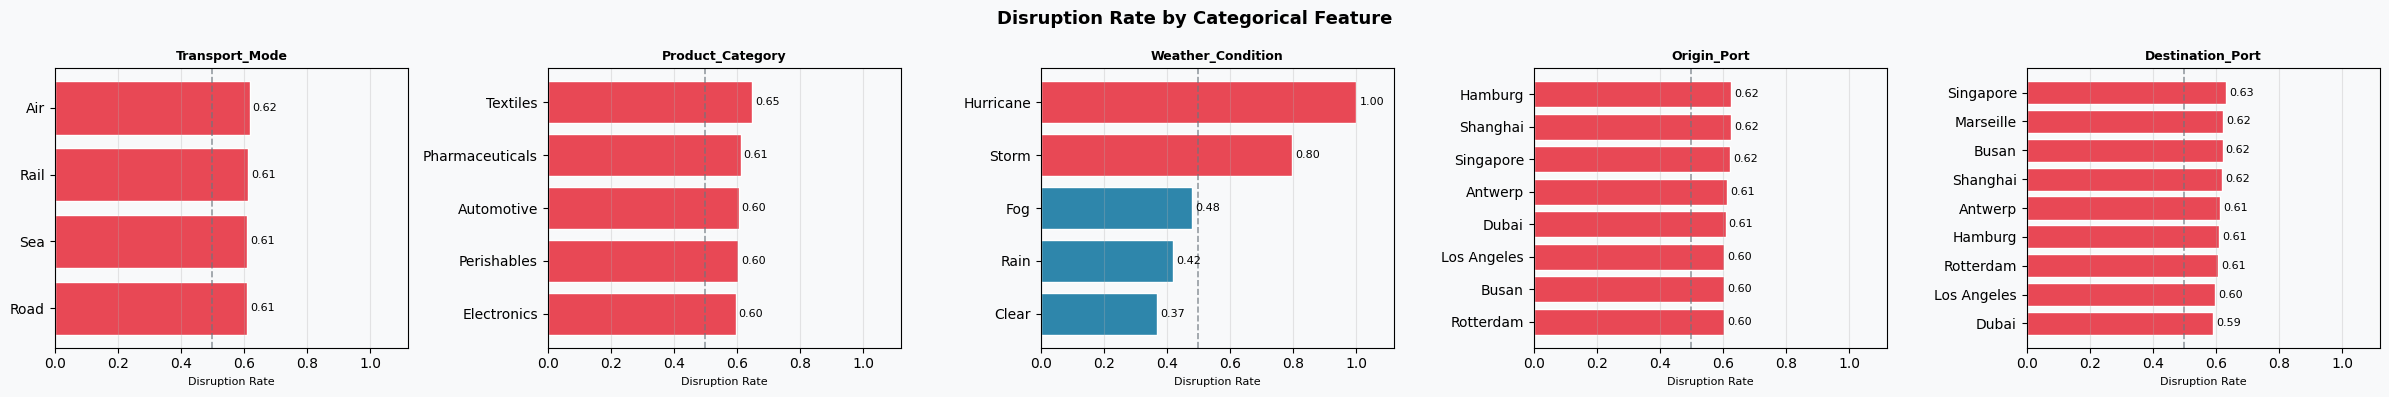

In [27]:
# ── Plot 15: Categorical panel (all 5 side by side)
cat_cols = ['Transport_Mode','Product_Category','Weather_Condition',
            'Origin_Port','Destination_Port']
fig, axes = plt.subplots(1, 5, figsize=(24, 4), facecolor=BG)
fig.suptitle('Disruption Rate by Categorical Feature', fontsize=13, fontweight='bold')
for ax, col in zip(axes, cat_cols):
    rates = df.groupby(col)['Disruption_Occurred'].mean().sort_values()
    colors = [C1 if r > 0.5 else C0 for r in rates.values]
    bars = ax.barh(rates.index, rates.values, color=colors, edgecolor='white')
    ax.axvline(0.5, color=GRAY, lw=1.2, ls='--', alpha=0.7)
    for bar, v in zip(bars, rates.values):
        ax.text(v+0.01, bar.get_y()+bar.get_height()/2,
                f'{v:.2f}', va='center', fontsize=8)
    ax.set_title(col, fontweight='bold', fontsize=9)
    ax.set_xlabel('Disruption Rate', fontsize=8)
    ax.set_xlim(0, 1.12); ax.set_facecolor(BG); ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/15_categorical_panel.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


### 2.4 Correlation Matrix

/opt/anaconda3/lib/python3.11/site-packages/seaborn/matrix.py:260: FutureWarning: Format strings passed to MaskedConstant are ignored, but in future may error or produce different behavior
  annotation = ("{:" + self.fmt + "}").format(val)


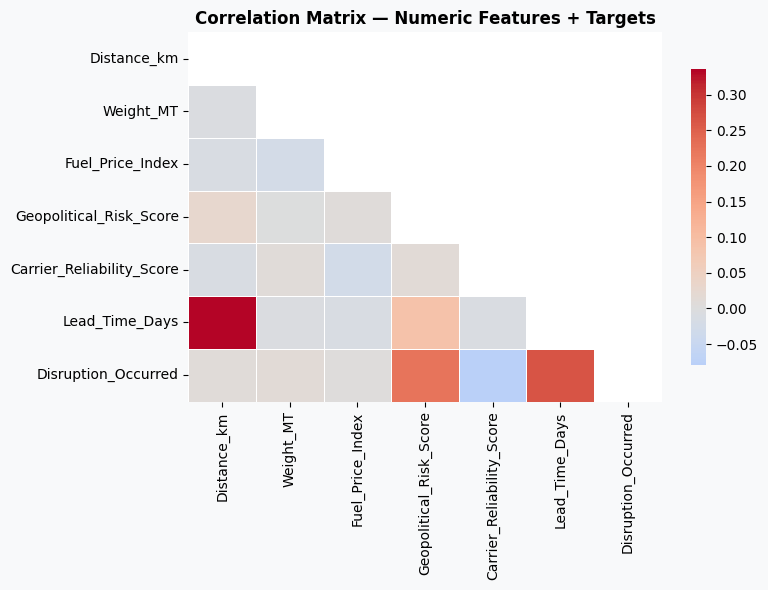

In [29]:
# ── Plot 16: Correlation heatmap
fig, ax = plt.subplots(figsize=(8, 6), facecolor=BG)
corr_cols = ['Distance_km','Weight_MT','Fuel_Price_Index',
             'Geopolitical_Risk_Score','Carrier_Reliability_Score',
             'Lead_Time_Days','Disruption_Occurred']
corr = df[corr_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))  # hide upper triangle
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, linewidths=0.5, cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Matrix — Numeric Features + Targets', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/16_correlation_heatmap.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


### 2.5 Boxplots

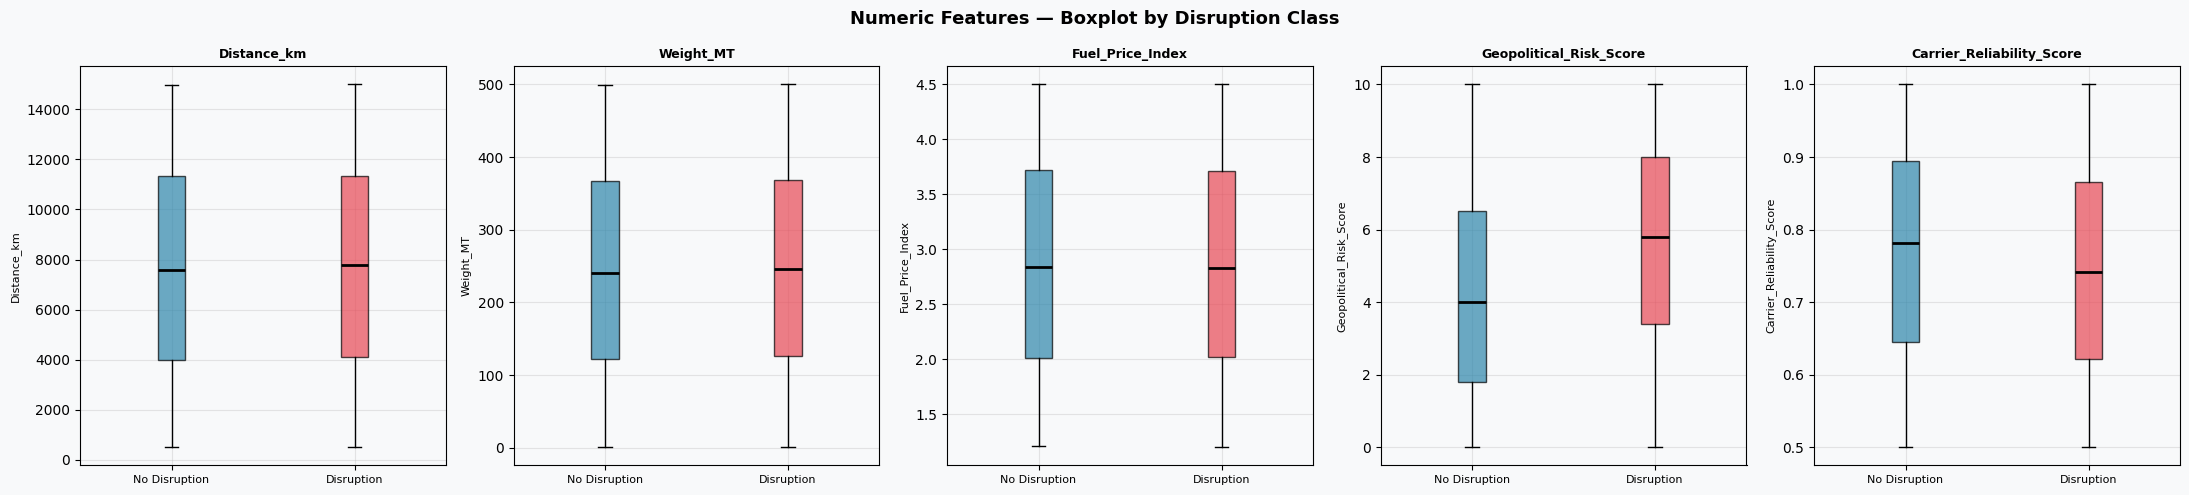

In [31]:
# ── Plot 17: Numeric boxplots by disruption class
num_cols = ['Distance_km','Weight_MT','Fuel_Price_Index',
            'Geopolitical_Risk_Score','Carrier_Reliability_Score']
fig, axes = plt.subplots(1, 5, figsize=(22, 5), facecolor=BG)
fig.suptitle('Numeric Features — Boxplot by Disruption Class',
             fontsize=13, fontweight='bold')
for ax, col in zip(axes, num_cols):
    data_bp = [df[df['Disruption_Occurred']==v][col].values for v in [0,1]]
    bp = ax.boxplot(data_bp, patch_artist=True,
                    medianprops=dict(color='black', lw=2))
    for patch, color in zip(bp['boxes'], [C0, C1]):
        patch.set_facecolor(color); patch.set_alpha(0.7)
    ax.set_xticklabels(['No Disruption', 'Disruption'], fontsize=8)
    ax.set_title(col, fontweight='bold', fontsize=9)
    ax.set_ylabel(col, fontsize=8); ax.set_facecolor(BG); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/17_numeric_boxplots.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


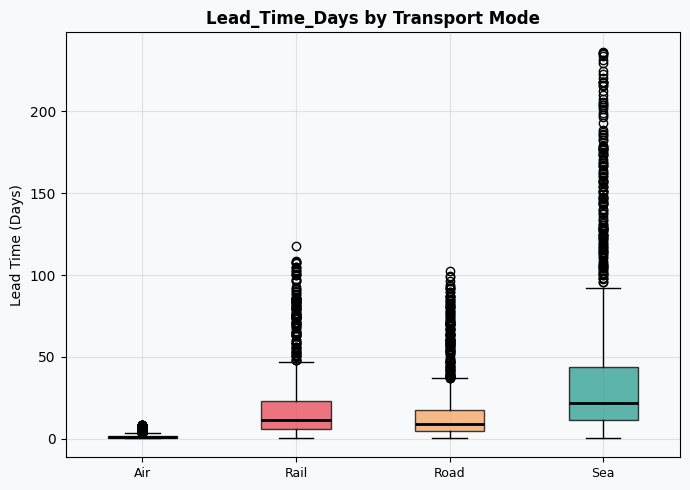

In [32]:
# ── Plot 18: Lead_Time boxplot by Transport Mode
fig, ax = plt.subplots(figsize=(7, 5), facecolor=BG)
modes = sorted(df['Transport_Mode'].unique())
data_bp = [df[df['Transport_Mode']==m]['Lead_Time_Days'].values for m in modes]
bp = ax.boxplot(data_bp, patch_artist=True,
                medianprops=dict(color='black', lw=2))
for patch, color in zip(bp['boxes'], ['#2E86AB','#E84855','#F4A261','#2A9D8F']):
    patch.set_facecolor(color); patch.set_alpha(0.75)
ax.set_xticklabels(modes, fontsize=9)
ax.set_title('Lead_Time_Days by Transport Mode', fontweight='bold')
ax.set_ylabel('Lead Time (Days)'); ax.set_facecolor(BG); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/18_leadtime_by_transport.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


## 3. Data Preprocessing

### 3.1 Drop Non-informative Columns & Separate Targets

In [35]:
# Drop ID and Date — no predictive signal
df_clean = df.drop(columns=['Shipment_ID', 'Date'])

y_cls = df_clean['Disruption_Occurred']   # classification target
y_reg = df_clean['Lead_Time_Days']        # regression target
X_raw = df_clean.drop(columns=['Disruption_Occurred', 'Lead_Time_Days'])

num_cols = ['Distance_km','Weight_MT','Fuel_Price_Index',
            'Geopolitical_Risk_Score','Carrier_Reliability_Score']
cat_cols = ['Origin_Port','Destination_Port','Transport_Mode',
            'Product_Category','Weather_Condition']

print(f'Feature matrix shape: {X_raw.shape}')
print(f'y_cls — 0:{(y_cls==0).sum()}  1:{(y_cls==1).sum()}')
print(f'y_reg range: {y_reg.min():.1f} – {y_reg.max():.1f} days')


Feature matrix shape: (5000, 10)
y_cls — 0:1937  1:3063
y_reg range: 0.5 – 236.4 days


### 3.2 Encode Categorical Features

- **One-Hot Encoding (OHE)** → Logistic Regression & Linear Regression (`drop_first=True`)
- **Label Encoding (LE)** → CART (trees split on integer codes natively)


In [37]:
# ── One-Hot Encoding (for linear models)
X_ohe = pd.get_dummies(X_raw, columns=cat_cols, drop_first=True)
print(f'OHE shape: {X_ohe.shape}')
print('Features:', list(X_ohe.columns))


OHE shape: (5000, 31)
Features: ['Distance_km', 'Weight_MT', 'Fuel_Price_Index', 'Geopolitical_Risk_Score', 'Carrier_Reliability_Score', 'Origin_Port_Busan', 'Origin_Port_Dubai', 'Origin_Port_Hamburg', 'Origin_Port_Los Angeles', 'Origin_Port_Rotterdam', 'Origin_Port_Shanghai', 'Origin_Port_Singapore', 'Destination_Port_Busan', 'Destination_Port_Dubai', 'Destination_Port_Hamburg', 'Destination_Port_Los Angeles', 'Destination_Port_Marseille', 'Destination_Port_Rotterdam', 'Destination_Port_Shanghai', 'Destination_Port_Singapore', 'Transport_Mode_Rail', 'Transport_Mode_Road', 'Transport_Mode_Sea', 'Product_Category_Electronics', 'Product_Category_Perishables', 'Product_Category_Pharmaceuticals', 'Product_Category_Textiles', 'Weather_Condition_Fog', 'Weather_Condition_Hurricane', 'Weather_Condition_Rain', 'Weather_Condition_Storm']


In [38]:
# ── Label Encoding (for CART)
X_le = X_raw.copy()
le_dict = {}   # store encoders for inverse_transform / interpretation
for col in cat_cols:
    le = LabelEncoder()
    X_le[col] = le.fit_transform(X_le[col])
    le_dict[col] = le
    print(f'{col}: {dict(enumerate(le.classes_))}')


Origin_Port: {0: 'Antwerp', 1: 'Busan', 2: 'Dubai', 3: 'Hamburg', 4: 'Los Angeles', 5: 'Rotterdam', 6: 'Shanghai', 7: 'Singapore'}
Destination_Port: {0: 'Antwerp', 1: 'Busan', 2: 'Dubai', 3: 'Hamburg', 4: 'Los Angeles', 5: 'Marseille', 6: 'Rotterdam', 7: 'Shanghai', 8: 'Singapore'}
Transport_Mode: {0: 'Air', 1: 'Rail', 2: 'Road', 3: 'Sea'}
Product_Category: {0: 'Automotive', 1: 'Electronics', 2: 'Perishables', 3: 'Pharmaceuticals', 4: 'Textiles'}
Weather_Condition: {0: 'Clear', 1: 'Fog', 2: 'Hurricane', 3: 'Rain', 4: 'Storm'}


### 3.3 Train / Test Split (80 / 20)

In [40]:
# stratify=y_cls preserves class balance in train and test
X_ohe_tr, X_ohe_te, y_cls_tr, y_cls_te = train_test_split(
    X_ohe, y_cls, test_size=0.2, random_state=SEED, stratify=y_cls)
X_le_tr,  X_le_te,  _,        _ = train_test_split(
    X_le,  y_cls, test_size=0.2, random_state=SEED, stratify=y_cls)

X_ohe_tr_r, X_ohe_te_r, y_reg_tr, y_reg_te = train_test_split(
    X_ohe, y_reg, test_size=0.2, random_state=SEED)
X_le_tr_r,  X_le_te_r,  _,        _ = train_test_split(
    X_le,  y_reg, test_size=0.2, random_state=SEED)

print(f'Train: {len(X_ohe_tr):,}  |  Test: {len(X_ohe_te):,}')
print(f'Class balance (train): {y_cls_tr.mean():.3f}')
print(f'Class balance (test):  {y_cls_te.mean():.3f}')


Train: 4,000  |  Test: 1,000
Class balance (train): 0.613
Class balance (test):  0.613


### 3.4 Scale Numeric Features

**StandardScaler** applied to numeric cols only.
- Used for **Logistic Regression** and **Linear Regression**
- **Not** applied to CART (trees are scale-invariant)
- Fit on train only → transform test with same parameters


In [42]:
# ── Classification scaler
scaler_cls = StandardScaler()
X_ohe_tr_sc = X_ohe_tr.copy(); X_ohe_te_sc = X_ohe_te.copy()
X_ohe_tr_sc[num_cols] = scaler_cls.fit_transform(X_ohe_tr[num_cols])
X_ohe_te_sc[num_cols] = scaler_cls.transform(X_ohe_te[num_cols])

# ── Regression scaler
scaler_reg = StandardScaler()
X_ohe_tr_r_sc = X_ohe_tr_r.copy(); X_ohe_te_r_sc = X_ohe_te_r.copy()
X_ohe_tr_r_sc[num_cols] = scaler_reg.fit_transform(X_ohe_tr_r[num_cols])
X_ohe_te_r_sc[num_cols] = scaler_reg.transform(X_ohe_te_r[num_cols])

# Verify: mean = 0, std = 1 on train
print(X_ohe_tr_sc[num_cols].describe().loc[['mean','std']].round(3))


      Distance_km  Weight_MT  Fuel_Price_Index  Geopolitical_Risk_Score  \
mean         -0.0       -0.0              -0.0                     -0.0   
std           1.0        1.0               1.0                      1.0   

      Carrier_Reliability_Score  
mean                        0.0  
std                         1.0  


### 3.5 Save Preprocessed Data

In [44]:
data = {
    # Classification
    'X_cls_train_scaled': X_ohe_tr_sc,  'X_cls_test_scaled': X_ohe_te_sc,
    'X_cls_train_le':     X_le_tr,      'X_cls_test_le':     X_le_te,
    # Regression
    'X_reg_train_scaled': X_ohe_tr_r_sc,'X_reg_test_scaled': X_ohe_te_r_sc,
    'X_reg_train_le':     X_le_tr_r,    'X_reg_test_le':     X_le_te_r,
    # Targets
    'y_cls_train': y_cls_tr, 'y_cls_test': y_cls_te,
    'y_reg_train': y_reg_tr, 'y_reg_test': y_reg_te,
    # Transformers
    'scaler_cls': scaler_cls, 'scaler_reg': scaler_reg, 'le_dict': le_dict,
    # Feature metadata
    'num_cols': num_cols, 'cat_cols': cat_cols,
    'ohe_feature_names': list(X_ohe.columns)
}
with open('preprocessed_data.pkl', 'wb') as f:
    pickle.dump(data, f)
print('Saved: preprocessed_data.pkl')

# List saved plots
import glob
saved = sorted(glob.glob(f'{PLOT_DIR}/*.png'))
print(f'\nSaved {len(saved)} plots in "{PLOT_DIR}/":')
for p in saved: print(' ', p)


Saved: preprocessed_data.pkl

Saved 18 plots in "plots/":
  plots/01_target_class_balance.png
  plots/02_lead_time_distribution.png
  plots/03_lead_time_by_disruption.png
  plots/04_num_distance_km.png
  plots/05_num_weight_mt.png
  plots/06_num_fuel_price_index.png
  plots/07_num_geopolitical_risk_score.png
  plots/08_num_carrier_reliability_score.png
  plots/09_numeric_features_panel.png
  plots/10_cat_transport_mode.png
  plots/11_cat_product_category.png
  plots/12_cat_weather_condition.png
  plots/13_cat_origin_port.png
  plots/14_cat_destination_port.png
  plots/15_categorical_panel.png
  plots/16_correlation_heatmap.png
  plots/17_numeric_boxplots.png
  plots/18_leadtime_by_transport.png


## 4. Preprocessing Summary

| Step | Detail |
|------|--------|
| **Dropped** | `Shipment_ID`, `Date` |
| **OHE** | `drop_first=True` -- 31 features (logistic / linear regression) |
| **Label Encoding** | Integer codes -- 10 features (CART) |
| **StandardScaler** | 5 numeric cols — fit on train only |
| **Train/Test** | 80/20 · `stratify=y_cls` · `random_state=42` |
| **Class balance** | Train 61.3% · Test 61.3% |
| **Plots saved** | 18 plots
